## Initialization

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import importlib

import Dynamics_double_pendulum, utilities.mppi, utilities.mpc
importlib.reload(Dynamics_double_pendulum)  # ensure latest file version is used
importlib.reload(utilities.mppi)
importlib.reload(utilities.mpc)

from Dynamics_double_pendulum import jax_dynamics
from utilities.mppi import MPPI
from utilities.mpc import DoublePendulumParams, build_double_pendulum_mpc, rollout_mpc
from utilities.mpc import CartPoleParams, build_cart_pole_mpc, rollout_cart_pole_mpc

/home/jixia/venv/lib/python3.12/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/home/jixia/venv/lib/python3.12/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')
/home/jixia/venv/lib/python3.12/site-packages/do_mpc/approximateMPC/__init__.py:13: UserWarning: The approximateMPC feature requires PyTorch, which is not installed by default. Please install the full version of do-mpc to use this feature: pip install do_mpc[full]
  warnings.warn('The approximateMPC feature requires PyTorch, which is not installed by default. Please install the

In [2]:
dt = 0.01
T  = 8.0
ratio_sim_mppi = 5

Q  = jnp.diag(jnp.array([60.0, 2.0, 60.0, 2.0], dtype=jnp.float32))
QT = jnp.diag(jnp.array([140.0, 5.0, 140.0, 5.0], dtype=jnp.float32))
R  = jnp.diag(jnp.array([1e-2, 1e-2], dtype=jnp.float32))
x_ref = jnp.array([0.0, 0.0, 0.0, 0.0], dtype=jnp.float32)

controller = MPPI(
    dyn_fn=jax_dynamics,
    dt=dt, horizon=60, n_samples=2000,
    Q=Q, QT=QT, R=R, x_ref=x_ref,
    noise_scale=jnp.array([4.0, 4.0]), temperature=1.0, seed=0
)
controller.set_sequence(jnp.zeros((60, 2), dtype=jnp.float32))

In [3]:
state = jnp.array([jnp.pi, 0.0, 0.0, 0.0], dtype=jnp.float32)

states = [np.array(state)]
controls = []

for t in np.arange(0.0, T, dt):
    u = controller.step(state)

    for _ in range(ratio_sim_mppi):
        state = jax_dynamics(state, u, dt=dt/ratio_sim_mppi)
    states.append(np.array(state))
    controls.append(np.array(u))

states = np.array(states)
controls = np.array(controls)

## Demo

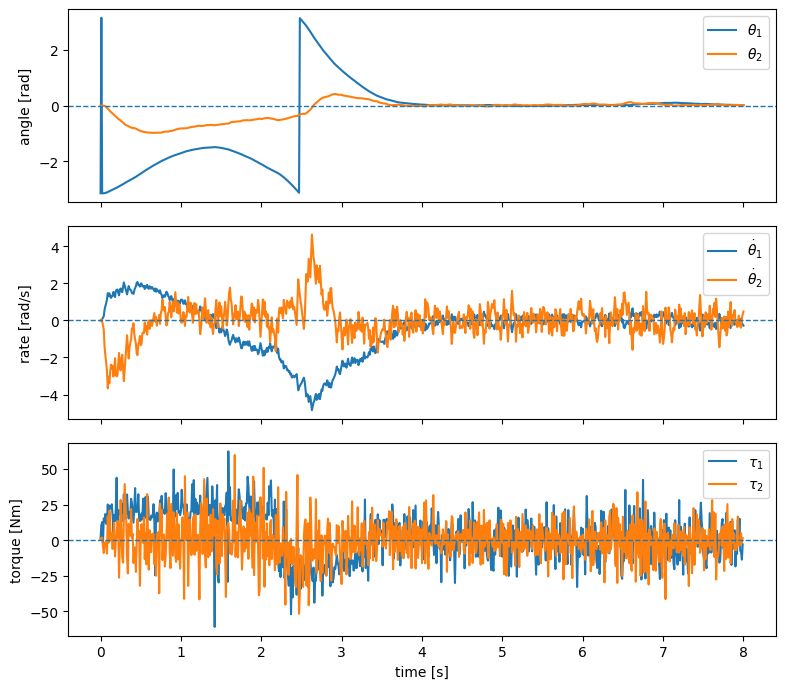

In [4]:
time = np.arange(states.shape[0]) * dt
fig, axs = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

axs[0].plot(time, (states[:, 0] + jnp.pi) % (2*jnp.pi) - jnp.pi, label=r'$\theta_1$')
axs[0].plot(time, (states[:, 2] + jnp.pi) % (2*jnp.pi) - jnp.pi, label=r'$\theta_2$')
axs[0].axhline(0, ls='--', lw=1); axs[0].legend(); axs[0].set_ylabel('angle [rad]')

axs[1].plot(time, states[:, 1], label=r'$\dot{\theta}_1$')
axs[1].plot(time, states[:, 3], label=r'$\dot{\theta}_2$')
axs[1].axhline(0, ls='--', lw=1); axs[1].legend(); axs[1].set_ylabel('rate [rad/s]')

axs[2].plot(time[:-1], controls[:, 0], label=r'$\tau_1$')
axs[2].plot(time[:-1], controls[:, 1], label=r'$\tau_2$')
axs[2].axhline(0, ls='--', lw=1); axs[2].legend(); axs[2].set_ylabel('torque [Nm]'); axs[2].set_xlabel('time [s]')
plt.tight_layout()
plt.show()



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



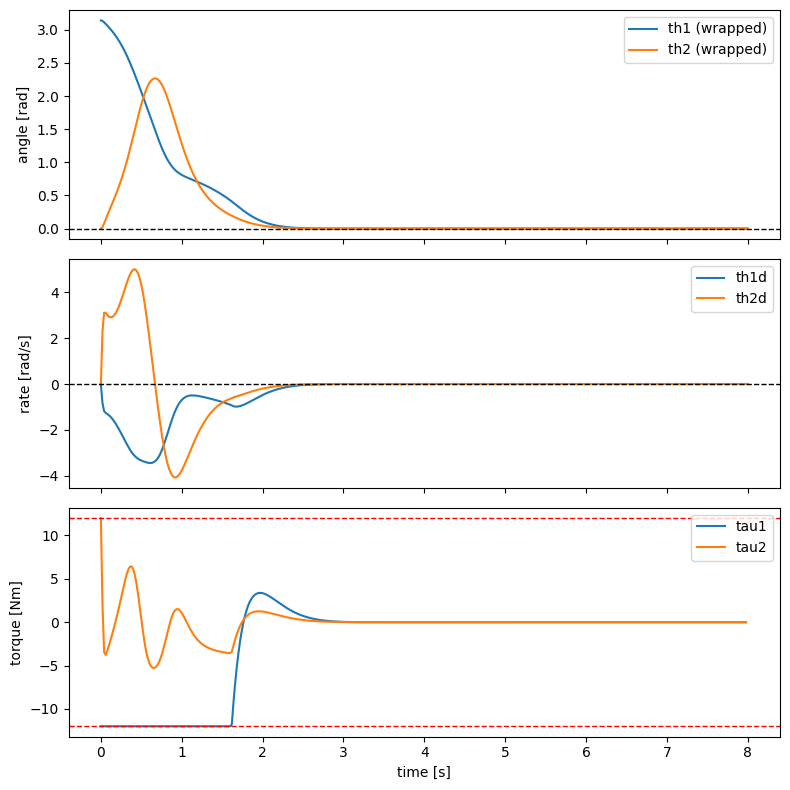

In [ ]:
import casadi as cs
import numpy as np
import do_mpc
import matplotlib.pyplot as plt

g  = 9.81
m1 = 1.0
m2 = 1.0
l1 = 1.0
l2 = 1.0
lc1 = 0.5
lc2 = 0.5
I1  = 0.2
I2  = 0.2

u_min = np.array([-12.0, -12.0])
u_max = np.array([+12.0, +12.0])

x_ref = np.array([0.0, 0.0, 0.0, 0.0])

Q  = np.diag([60.0, 2.0, 60.0, 2.0])
QT = np.diag([140.0, 5.0, 140.0, 5.0])
R  = np.diag([1e-2, 1e-2])

def wrap(a):
    return cs.atan2(cs.sin(a), cs.cos(a))

model = do_mpc.model.Model('continuous')

th1  = model.set_variable('_x', 'th1')
th1d = model.set_variable('_x', 'th1d')
th2  = model.set_variable('_x', 'th2')
th2d = model.set_variable('_x', 'th2d')

tau1 = model.set_variable('_u', 'tau1')
tau2 = model.set_variable('_u', 'tau2')

c2 = cs.cos(th2)
s2 = cs.sin(th2)

d11 = I1 + I2 + m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2)
d12 = I2 + m2*(lc2**2 + l1*lc2*c2)
d21 = d12
d22 = I2 + m2*lc2**2
D = cs.vertcat(
    cs.hcat([d11, d12]),
    cs.hcat([d21, d22])
)

h = m2*l1*lc2*s2
c1 = -2.0*h*th1d*th2d - h*th2d**2
c2_term = h*th1d**2
Cqd = cs.vertcat(c1, c2_term)

g1 = -(m1*lc1 + m2*l1)*g*cs.sin(th1) - m2*lc2*g*cs.sin(th1 + th2)
g2 = -m2*lc2*g*cs.sin(th1 + th2)
Gv = cs.vertcat(g1, g2)

tau = cs.vertcat(tau1, tau2)
rhs = tau - Cqd - Gv
ddq = cs.solve(D, rhs)

model.set_rhs('th1',  th1d)
model.set_rhs('th1d', ddq[0])
model.set_rhs('th2',  th2d)
model.set_rhs('th2d', ddq[1])

model.setup()

mpc = do_mpc.controller.MPC(model)

dt = 0.02
mpc.set_param(
    n_horizon=120,
    t_step=dt,
    state_discretization='collocation',
    collocation_type='legendre',
    n_robust=0,
    store_full_solution=True,
    nlpsol_opts={'ipopt': {'print_level': 0}, 'print_time': 0}
)

e_th1  = wrap(th1 - x_ref[0])
e_th1d = (th1d - x_ref[1])
e_th2  = wrap(th2 - x_ref[2])
e_th2d = (th2d - x_ref[3])

e_vec  = cs.vertcat(e_th1, e_th1d, e_th2, e_th2d)
u_vec  = cs.vertcat(tau1, tau2)

lterm = cs.mtimes([e_vec.T, cs.DM(Q),  e_vec]) + cs.mtimes([u_vec.T, cs.DM(R),  u_vec])
mterm = cs.mtimes([e_vec.T, cs.DM(QT), e_vec])

mpc.set_objective(mterm=mterm, lterm=lterm)
mpc.set_rterm(tau1=1e-4, tau2=1e-4)

mpc.bounds['lower','_u','tau1'] = u_min[0]
mpc.bounds['upper','_u','tau1'] = u_max[0]
mpc.bounds['lower','_u','tau2'] = u_min[1]
mpc.bounds['upper','_u','tau2'] = u_max[1]

mpc.setup()

simulator = do_mpc.simulator.Simulator(model)
simulator.set_param(t_step=dt)
simulator.setup()

x0 = np.array([np.pi, 0.0, 0.0, 0.0]) 
mpc.x0 = x0
simulator.x0 = x0
mpc.set_initial_guess()

N = int(8.0 / dt)  

X = np.zeros((N+1, 4))
U = np.zeros((N, 2))
T = np.zeros(N+1)
X[0,:] = x0

x = x0.copy()
for k in range(N):
    u = mpc.make_step(x)
    x = simulator.make_step(u)

    X[k+1,:] = x.squeeze()
    U[k,:]   = u.squeeze()
    T[k+1]   = T[k] + dt

fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
axs[0].plot(T, (np.angle(np.exp(1j*X[:,0]))), label='th1 (wrapped)')
axs[0].plot(T, (np.angle(np.exp(1j*X[:,2]))), label='th2 (wrapped)')
axs[0].axhline(0.0, ls='--', lw=1, color='k')
axs[0].set_ylabel('angle [rad]')
axs[0].legend()

axs[1].plot(T, X[:,1], label='th1d')
axs[1].plot(T, X[:,3], label='th2d')
axs[1].axhline(0.0, ls='--', lw=1, color='k')
axs[1].set_ylabel('rate [rad/s]')
axs[1].legend()

axs[2].plot(T[:-1], U[:,0], label='tau1')
axs[2].plot(T[:-1], U[:,1], label='tau2')
axs[2].axhline(u_min[0], ls='--', lw=1, color='r')
axs[2].axhline(u_max[0], ls='--', lw=1, color='r')
axs[2].set_ylabel('torque [Nm]')
axs[2].set_xlabel('time [s]')
axs[2].legend()
plt.tight_layout()
plt.show()

## Recurrent Condition Verification

### Expert Data Synthesis

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     7684
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     3362

Total number of variables............................:     2176
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      240
                     variables with only upper bounds:        0
Total number of equality constraints.................:     1924
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  7.2442896e+04 2.66e-15 4.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

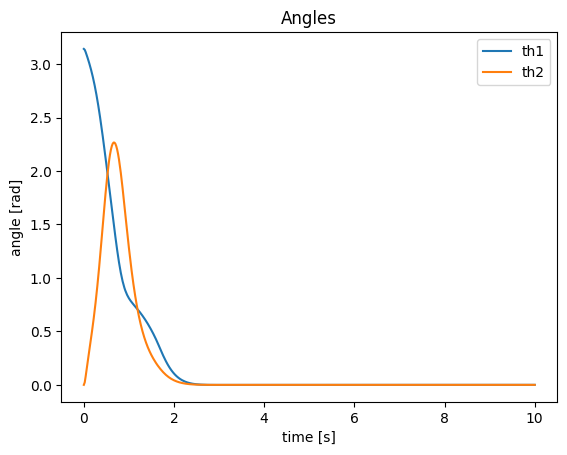

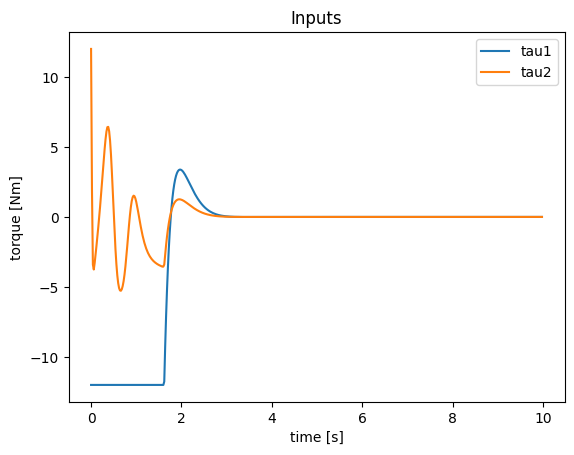

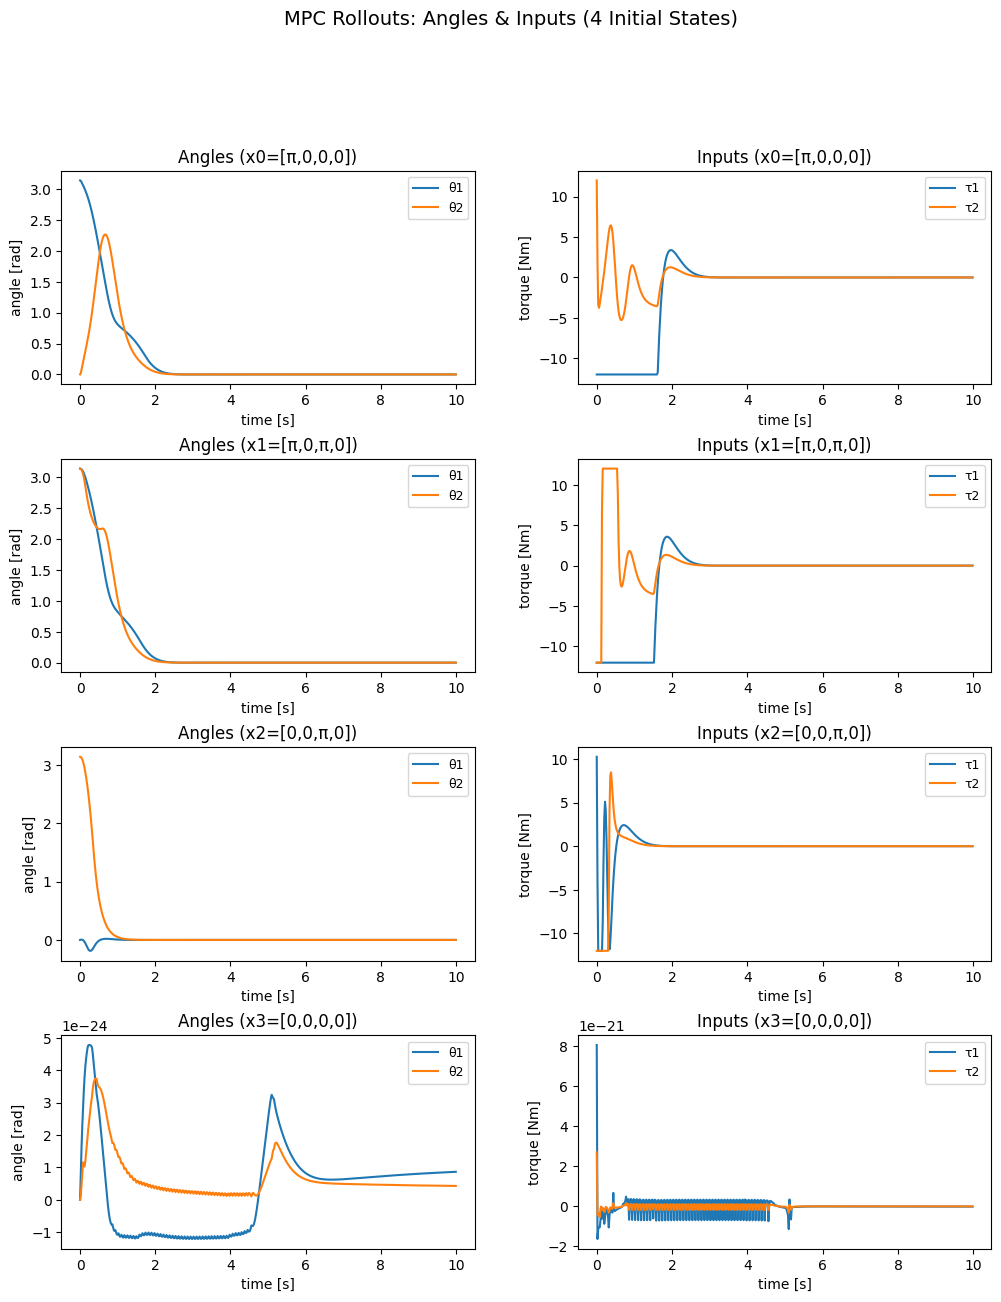

Saved .npy files to: /home/jixia/myenv/Nonparameric_Hamiltonian_Systems/data


In [6]:
cfg = DoublePendulumParams(dt=0.02, n_horizon=120)  # defaults already match your script
model, mpc, simulator = build_double_pendulum_mpc(cfg)

simulator.t_step = cfg.dt

x0 = np.array([np.pi, 0.0, 0.0, 0.0], dtype=float)
x1 = np.array([np.pi, 0.0, np.pi, 0.0], dtype=float)
x2 = np.array([0.0, 0.0, np.pi, 0.0], dtype=float)
x3 = np.array([0.0, 0.0, 0.0, 0.0], dtype=float)

T0, X0, U0 = rollout_mpc(mpc, simulator, x0, sim_time=10.0, save_U=True, save_prefix="demo")
T1, X1, U1 = rollout_mpc(mpc, simulator, x1, sim_time=10.0, save_U=True, save_prefix="demo")
T2, X2, U2 = rollout_mpc(mpc, simulator, x2, sim_time=10.0, save_U=True, save_prefix="demo")
T3, X3, U3 = rollout_mpc(mpc, simulator, x3, sim_time=10.0, save_U=True, save_prefix="demo")

print("Shapes -> T:", T0.shape, " X:", X0.shape, " U:", U0.shape)
print("First control:", U0[0])
plt.figure()
plt.plot(T0, X0[:,0], label='th1')
plt.plot(T0, X0[:,2], label='th2')
plt.legend()
plt.xlabel('time [s]'); plt.ylabel('angle [rad]')
plt.title('Angles')

plt.figure()
plt.plot(T0[:-1], U0[:,0], label='tau1')
plt.plot(T0[:-1], U0[:,1], label='tau2')
plt.legend()
plt.xlabel('time [s]'); plt.ylabel('torque [Nm]')
plt.title('Inputs')
plt.show()

import matplotlib.pyplot as plt

cases = [
    ("x0=[π,0,0,0]",   T0, X0, U0),
    ("x1=[π,0,π,0]",   T1, X1, U1),
    ("x2=[0,0,π,0]",   T2, X2, U2),
    ("x3=[0,0,0,0]",   T3, X3, U3),
]

fig = plt.figure(figsize=(12, 14))
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.25)

for r, (name, T, X, U) in enumerate(cases):
    ax_th = fig.add_subplot(gs[r, 0])
    ax_th.plot(T, X[:, 0], label='θ1')
    ax_th.plot(T, X[:, 2], label='θ2')
    ax_th.set_title(f'Angles ({name})')
    ax_th.set_xlabel('time [s]')
    ax_th.set_ylabel('angle [rad]')
    ax_th.legend(loc='best', fontsize=9)

    ax_u = fig.add_subplot(gs[r, 1])
    t_u = T[:-1] if U.shape[0] == T.shape[0]-1 else T[:U.shape[0]]
    ax_u.plot(t_u, U[:, 0], label='τ1')
    ax_u.plot(t_u, U[:, 1], label='τ2')
    ax_u.set_title(f'Inputs ({name})')
    ax_u.set_xlabel('time [s]')
    ax_u.set_ylabel('torque [Nm]')
    ax_u.legend(loc='best', fontsize=9)

fig.suptitle('MPC Rollouts: Angles & Inputs (4 Initial States)', y=0.995, fontsize=14)
plt.show()

import os
import numpy as np

save_dir = os.path.expanduser('~/myenv/Nonparameric_Hamiltonian_Systems/data')
os.makedirs(save_dir, exist_ok=True)

names = {
    "x0_pi_0_0_0"  : (T0, X0, U0),
    "x1_pi_0_pi_0" : (T1, X1, U1),
    "x2_0_0_pi_0"  : (T2, X2, U2),
    "x3_0_0_0_0"   : (T3, X3, U3),
}

for name, (T, X, U) in names.items():
    np.save(os.path.join(save_dir, f"T_{name}.npy"), T)
    np.save(os.path.join(save_dir, f"X_{name}.npy"), X)
    np.save(os.path.join(save_dir, f"U_{name}.npy"), U)

print("Saved .npy files to:", save_dir)

### Energy Computation

In [ ]:
save_dir = os.path.expanduser('~/myenv/Nonparameric_Hamiltonian_Systems/data')
names = [
    "x0_pi_0_0_0",
    "x1_pi_0_pi_0",
    "x2_0_0_pi_0",
    "x3_0_0_0_0",
]

g  = 9.81
m1 = 1.0; m2 = 1.0
l1 = 1.0; l2 = 1.0
lc1 = 0.5; lc2 = 0.5
I1 = 0.2;  I2 = 0.2
A  = (m1*lc1 + m2*l1)
m2lc2g = m2*lc2*g

def energies_from_X(X):
    th1  = X[:, 0]
    th1d = X[:, 1]
    th2  = X[:, 2]
    th2d = X[:, 3]

    c2 = np.cos(th2)

    d11 = I1 + I2 + m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2)
    d12 = I2 + m2*(lc2**2 + l1*lc2*c2)
    d22 = I2 + m2*lc2**2

    K = 0.5*(d11*th1d**2 + 2.0*d12*th1d*th2d + d22*th2d**2)
    
    V_phys = A*g*np.cos(th1) + m2*lc2*g*np.cos(th1 + th2)
    V_ref  = (A + m2*lc2)*g
    V = V_phys - V_ref

    H = K + V
    return K, V, H

for name in names:
    X = np.load(os.path.join(save_dir, f"X_{name}.npy"))
    K, V, H = energies_from_X(X)

    np.save(os.path.join(save_dir, f"Ekin_{name}.npy"), K)
    np.save(os.path.join(save_dir, f"Epot_{name}.npy"), V)
    np.save(os.path.join(save_dir, f"H_total_{name}.npy"), H)

print("Saved energy files (.npy) to:", save_dir)

def LH_from_X(X):
    th1  = X[:, 0]
    w1   = X[:, 1]
    th2  = X[:, 2]
    w2   = X[:, 3]

    c2 = np.cos(th2)
    s2 = np.sin(th2)

    d11 = I1 + I2 + m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2)
    d12 = I2 + m2*(lc2**2 + l1*lc2*c2)
    d22 = I2 + m2*lc2**2

    dd11_dth2 = -2*m2*l1*lc2*s2
    dd12_dth2 = -  m2*l1*lc2*s2

    dH_dth1 = -A*g*np.sin(th1) - m2lc2g*np.sin(th1 + th2)
    dH_dth2 = 0.5*dd11_dth2*w1**2 + dd12_dth2*w1*w2 - m2lc2g*np.sin(th1 + th2)
    dH_dw1  = d11*w1 + d12*w2
    dH_dw2  = d12*w1 + d22*w2

    L = np.sqrt(dH_dth1**2 + dH_dth2**2 + dH_dw1**2 + dH_dw2**2)
    return L

save_dir = os.path.expanduser('~/myenv/Nonparameric_Hamiltonian_Systems/data')
names = [
    "x0_pi_0_0_0",
    "x1_pi_0_pi_0",
    "x2_0_0_pi_0",
    "x3_0_0_0_0",
]

for name in names:
    X = np.load(os.path.join(save_dir, f"X_{name}.npy"))
    L = LH_from_X(X)
    np.save(os.path.join(save_dir, f"LH_{name}.npy"), L)
    print(name, "-> L_H max:", float(L.max()))

Saved energy files (.npy) to: /home/jixia/myenv/Nonparameric_Hamiltonian_Systems/data
x0_pi_0_0_0 -> L_H max: 16.572201930832506
x1_pi_0_pi_0 -> L_H max: 17.27289934798046
x2_0_0_pi_0 -> L_H max: 6.21484558267111
x3_0_0_0_0 -> L_H max: 1.7087794495545103e-22


### Radius Computation based on Energy

In [ ]:
rho = 0.99
epsilon = 1e-5

H_star = 0

def energies_H_from_X(X):
    th1  = X[:, 0]
    w1   = X[:, 1]
    th2  = X[:, 2]
    w2   = X[:, 3]

    c2 = np.cos(th2)

    d11 = I1 + I2 + m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2)
    d12 = I2 + m2*(lc2**2 + l1*lc2*c2)
    d22 = I2 + m2*lc2**2  # 0.45

    K = 0.5*(d11*w1**2 + 2.0*d12*w1*w2 + d22*w2**2)

    V_phys = A*g*np.cos(th1) + m2*lc2*g*np.cos(th1 + th2)
    V_ref  = (A + m2*lc2)*g
    V = V_phys - V_ref

    H = K + V
    return H

def LH_from_X(X):
    th1  = X[:, 0]
    w1   = X[:, 1]
    th2  = X[:, 2]
    w2   = X[:, 3]

    c2 = np.cos(th2)
    s2 = np.sin(th2)

    # Inertia entries
    d11 = I1 + I2 + m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2)
    d12 = I2 + m2*(lc2**2 + l1*lc2*c2)
    d22 = I2 + m2*lc2**2

    # theta2 derivatives
    dd11_dth2 = -2*m2*l1*lc2*s2   # = -1.0 * sin(th2)
    dd12_dth2 = -  m2*l1*lc2*s2   # = -0.5 * sin(th2)
    dH_dth1 = -A*g*np.sin(th1) - m2lc2g*np.sin(th1 + th2)
    dH_dth2 = 0.5*dd11_dth2*w1**2 + dd12_dth2*w1*w2 - m2lc2g*np.sin(th1 + th2)
    dH_dw1  = d11*w1 + d12*w2
    dH_dw2  = d12*w1 + d22*w2

    L = np.sqrt(dH_dth1**2 + dH_dth2**2 + dH_dw1**2 + dH_dw2**2)
    return L

# ---------------------------------------
# Solve r_i from: |H_{i+1}-H*| + LHi * r_i * exp(L*dt) = rho * (|H_i-H*| - L_H * r_i)
# ---------------------------------------
def compute_r_vector(T, H, LH_pointwise, L_H_global, rho, eps, Ldyn):
    Habs = np.abs(H - H_star)
    dt = np.median(np.diff(T)) if len(T) > 1 else 0.0
    expo = np.exp(Ldyn * dt)

    N = len(H) - 1 
    r = np.empty_like(Habs)
    for i in range(N):
        A = Habs[i+1]
        B = LH_pointwise[i] * expo
        C = Habs[i]
        D = L_H_global

        denom = B + rho * D
        numer = rho * C - A

        if denom <= 1e-12:
            r_i = eps
        else:
            r_i = numer / denom
            if r_i <= 0.0:
                r_i = eps
        r[i] = r_i

    r[-1] = eps
    return r, dt

# Pipeline
all_LH = []
TX = {}
for name in names:
    X = np.load(os.path.join(save_dir, f"X_{name}.npy"))  # (N+1,4)
    T = np.load(os.path.join(save_dir, f"T_{name}.npy"))  # (N+1,)
    LH = LH_from_X(X)
    H  = energies_H_from_X(X)
    TX[name] = {"X": X, "T": T, "LH": LH, "H": H}
    all_LH.append(LH.max())

L_H_global = float(np.max(all_LH))

print(f"[Global] L_H (global max over all trajectories): {L_H_global:.6f}")

for name in names:
    T  = TX[name]["T"]
    H  = TX[name]["H"]
    LH = TX[name]["LH"]

    r, dt = compute_r_vector(T, H, LH, L_H_global, rho, epsilon, 1)

    np.save(os.path.join(save_dir, f"r_{name}.npy"), r)
    np.save(os.path.join(save_dir, f"LH_{name}.npy"), LH)
    np.save(os.path.join(save_dir, f"H_{name}.npy"),  H)

    print(f"{name}: dt={dt:.6f}, "
          f"LH_max={LH.max():.6f}, LH_min={LH.min():.6f}, "
          f"r_min={r.min():.6e}, r_max={r.max():.6e}")

print("Done. r_i, L_H, H per trajectory saved to:", save_dir)

[Global] L_H (global max over all trajectories): 17.272899
x0_pi_0_0_0: dt=0.020000, LH_max=16.572202, LH_min=0.000000, r_min=1.305542e-34, r_max=4.030569e-02
x1_pi_0_pi_0: dt=0.020000, LH_max=17.272899, LH_min=0.000000, r_min=5.770055e-35, r_max=5.720366e-02
x2_0_0_pi_0: dt=0.020000, LH_max=6.214846, LH_min=0.000000, r_min=6.159499e-41, r_max=6.437035e-02
x3_0_0_0_0: dt=0.020000, LH_max=0.000000, LH_min=0.000000, r_min=8.014549e-54, r_max=1.000000e-05
Done. r_i, L_H, H per trajectory saved to: /home/jixia/myenv/Nonparameric_Hamiltonian_Systems/data


### Control Policy

# Cart Pole

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     7444
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     1683

Total number of variables............................:     2056
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      120
                     variables with only upper bounds:        0
Total number of equality constraints.................:     1924
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  7.2442896e+04 2.66e-15 5.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

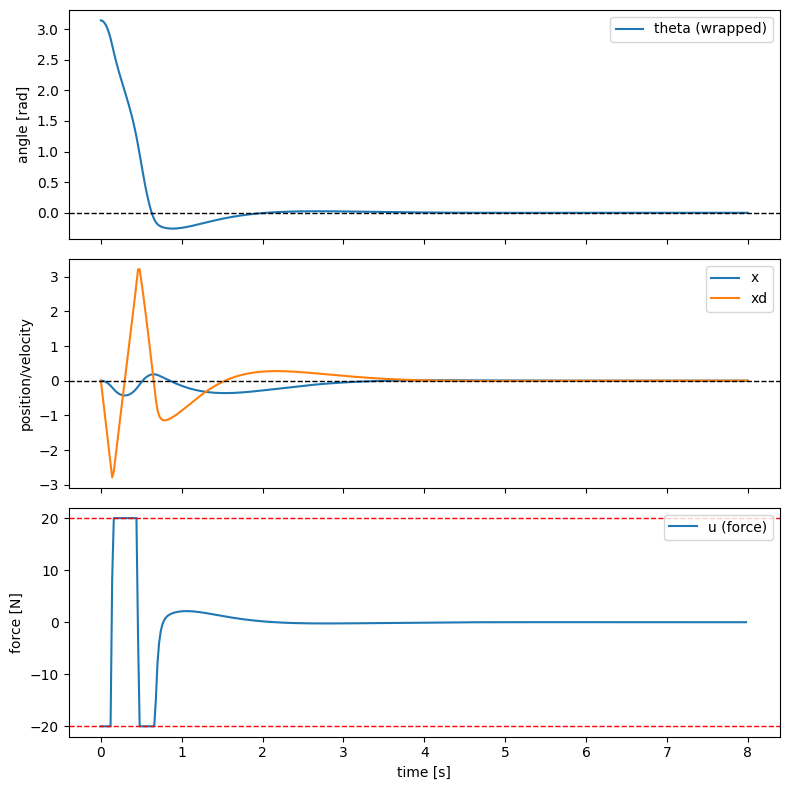

In [9]:
import casadi as cs
import numpy as np
import do_mpc
import matplotlib.pyplot as plt

def wrap(a):
    return np.arctan2(np.sin(a), np.cos(a))

cfg = CartPoleParams(
    g=9.81,
    mc=1.0,          
    mp=0.1,          
    l=0.5,           
    Ip=0.0,          
    u_min=-20.0,
    u_max=+20.0,
    Q = np.diag([5.0, 1.0, 60.0, 2.0]),     # [x, xd, th, thd]
    QT= np.diag([10.0, 2.0, 140.0, 5.0]),
    R = np.array([[1e-2]]),
    dt=0.02,
    n_horizon=120,
    collocation_type='legendre',
)

model, mpc, simulator = build_cart_pole_mpc(cfg)

x0 = np.array([0.0, 0.0, np.pi, 0.0])
simulator.t_step = cfg.dt

T, X, U = rollout_cart_pole_mpc(mpc, simulator, x0, sim_time=8.0, save_U=True)

fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axs[0].plot(T, wrap(X[:,2]), label='theta (wrapped)')
axs[0].axhline(0.0, ls='--', lw=1, color='k')
axs[0].set_ylabel('angle [rad]')
axs[0].legend()

axs[1].plot(T, X[:,0], label='x')
axs[1].plot(T, X[:,1], label='xd')
axs[1].axhline(0.0, ls='--', lw=1, color='k')
axs[1].set_ylabel('position/velocity')
axs[1].legend()

axs[2].plot(T[:-1], U[:,0], label='u (force)')
axs[2].axhline(cfg.u_min, ls='--', lw=1, color='r')
axs[2].axhline(cfg.u_max, ls='--', lw=1, color='r')
axs[2].set_ylabel('force [N]')
axs[2].set_xlabel('time [s]')
axs[2].legend()

plt.tight_layout()
plt.show()

## Baseline
### PPO

In [4]:
import numpy as np
import torch
import torch.nn as nn

from Dynamics_double_pendulum import DoublePendulumEnv
from baseline.ppo import PPO

# --------------------------------------------------
# 1. 定义一个简单的 Neural Network 模块
# --------------------------------------------------
class MLPPolicy(nn.Module):
    """
    一个简单的多层感知机，用作 actor / critic。
    构造方式：MLPPolicy(obs_dim, out_dim)
    """
    def __init__(self, obs_dim: int, out_dim: int):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, out_dim),
        )

    def forward(self, x):
        # 允许传入 numpy 数组
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32)
        return self.net(x)


# --------------------------------------------------
# 2. 创建环境和 PPO agent
# --------------------------------------------------
env = DoublePendulumEnv(
    dt=0.02,
    episode_seconds=8.0,
)

agent = PPO(
    policy_class=MLPPolicy,
    env=env,
    # 可以按需覆盖超参数：
    timesteps_per_batch=4096,
    max_timesteps_per_episode=800,
    n_updates_per_iteration=5,
    lr=3e-4,
    gamma=0.99,
    clip=0.2,
    render=False,   # DoublePendulumEnv 暂时没实现 render，保持 False
    seed=0,
)

# --------------------------------------------------
# 3. 开始训练
# --------------------------------------------------
total_timesteps = 200_000  # 可以先设小一点比如 20_000 试运行
agent.learn(total_timesteps=total_timesteps)

Learning... Running 800 timesteps per episode, 4096 timesteps per batch for a total of 200000 timesteps

-------------------- Iteration #1 --------------------
Average Episodic Length: 400.0
Average Episodic Return: -230935.0
Average Actor Loss: -0.00103
Timesteps So Far: 4400
Iteration took: 15.29 secs
------------------------------------------------------


-------------------- Iteration #2 --------------------
Average Episodic Length: 400.0
Average Episodic Return: -229213.23
Average Actor Loss: -0.00142
Timesteps So Far: 8800
Iteration took: 16.56 secs
------------------------------------------------------


-------------------- Iteration #3 --------------------
Average Episodic Length: 400.0
Average Episodic Return: -230959.32
Average Actor Loss: -0.00065
Timesteps So Far: 13200
Iteration took: 12.71 secs
------------------------------------------------------


-------------------- Iteration #4 --------------------
Average Episodic Length: 400.0
Average Episodic Return: -230982.14

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt


def rollout_deterministic(env, agent, max_steps=None, x0=None):
    if x0 is not None:
        obs, info = env.reset(options={"x0": np.array(x0, dtype=np.float32)})
    else:
        obs, info = env.reset()

    states = []
    actions = []
    rewards = []

    if max_steps is None:
        max_steps = env.horizon_steps

    for k in range(max_steps):
        states.append(obs.copy())

        obs_tensor = torch.tensor(obs, dtype=torch.float32)
        with torch.no_grad():
            mean_action = agent.actor(obs_tensor)
        action = mean_action.cpu().numpy()

        obs, reward, terminated, truncated, info = env.step(action)

        actions.append(action.copy())
        rewards.append(reward)

        if terminated or truncated:
            break

    return np.array(states), np.array(actions), np.array(rewards)


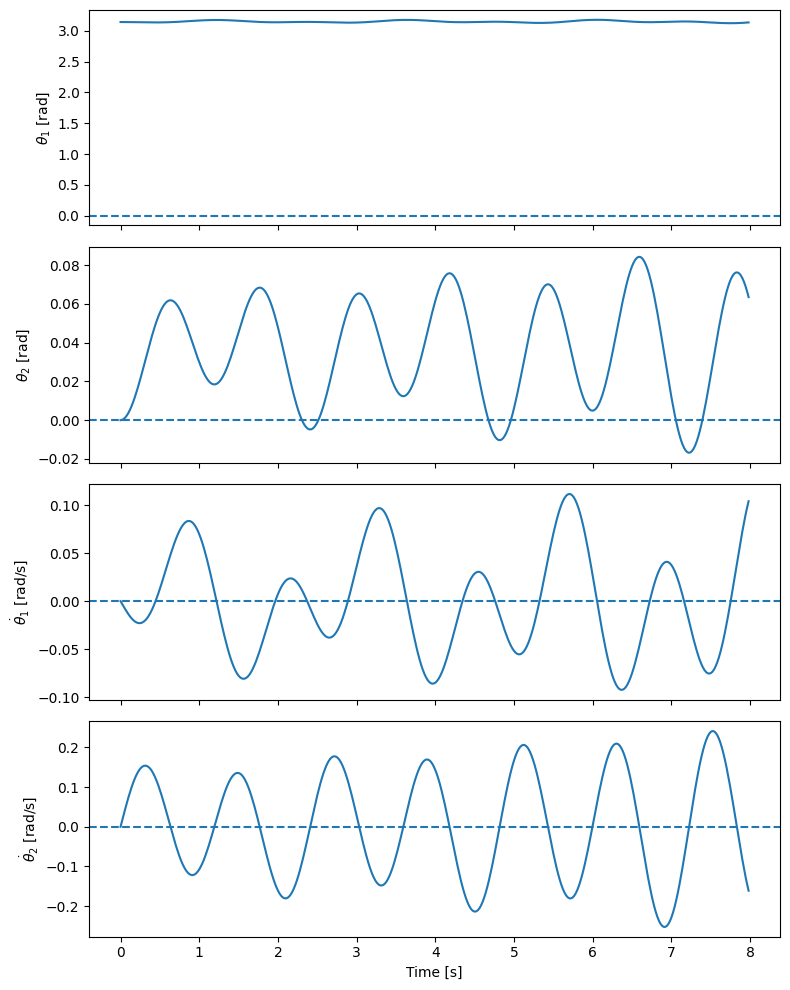

In [8]:
# 这里假设 agent 已经训练好（或者你从 pth 文件里 load 了权重）

# 可以显式指定初始状态（也可以不传 x0，用环境自己的 reset 逻辑）
x0 = [np.pi, 0.0, 0.0, 0.0]  # swing-up 初始姿态
states, actions, rewards = rollout_deterministic(env, agent, x0=x0)

# 时间轴
dt = env.dt
T = states.shape[0]
t = np.arange(T) * dt

# 拆状态
th1   = states[:, 0]
th1d  = states[:, 1]
th2   = states[:, 2]
th2d  = states[:, 3]

# 画图：四个子图，对应 θ1, θ2, θ̇1, θ̇2
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

axes[0].plot(t, th1)
axes[0].axhline(0.0, linestyle="--")
axes[0].set_ylabel(r"$\theta_1$ [rad]")

axes[1].plot(t, th2)
axes[1].axhline(0.0, linestyle="--")
axes[1].set_ylabel(r"$\theta_2$ [rad]")

axes[2].plot(t, th1d)
axes[2].axhline(0.0, linestyle="--")
axes[2].set_ylabel(r"$\dot{\theta}_1$ [rad/s]")

axes[3].plot(t, th2d)
axes[3].axhline(0.0, linestyle="--")
axes[3].set_ylabel(r"$\dot{\theta}_2$ [rad/s]")
axes[3].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()
